In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import opendatasets as od


In [4]:
od.download("https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho")

Skipping, found downloaded files in ".\vehicle-dataset-from-cardekho" (use force=True to force download)


In [5]:
df1 = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Music\\NTI\\vehicle-dataset-from-cardekho\\CAR DETAILS FROM CAR DEKHO.csv")
df2 = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Music\\NTI\\vehicle-dataset-from-cardekho\\Car details v3.csv")
df3 = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Music\\NTI\\vehicle-dataset-from-cardekho\\car data.csv")
df4 = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Music\\NTI\\vehicle-dataset-from-cardekho\\car details v4.csv")

In [6]:
print(df1.columns)
print(df2.columns)
print(df3.columns)
print(df4.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')
Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')
Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')


In [7]:
df1 = df1.rename(columns={"selling_price" : "price"})
df2 = df2.rename(columns={
    "selling_price": "price"
})
df3 = df3.rename(columns={
    "Car_Name": "name",
    "Year": "year",
    "Selling_Price": "price",
    "Kms_Driven": "km_driven",
    "Fuel_Type": "fuel",
    "Seller_Type": "seller_type",
    "Transmission": "transmission",
    "Owner": "owner"
})
df4 = df4.rename(columns={
    "Make": "name",
    "Price": "price",
    "Kilometer": "km_driven",
    "Fuel Type": "fuel",
    "Seller Type": "seller_type",
    "Transmission": "transmission",
    "Owner": "owner",
    "Year": "year"
})

In [8]:
cols = ["name", "year", "price", "km_driven",
        "fuel", "seller_type", "transmission", "owner"]

df1 = df1.reindex(columns=cols)
df2 = df2.reindex(columns=cols)
df3 = df3.reindex(columns=cols)
df4 = df4.reindex(columns=cols)

In [9]:
df1.head()



,name,year,price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [10]:
df2.head()

,name,year,price,km_driven,fuel,seller_type,transmission,owner
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner


In [11]:
df3.head()

,name,year,price,km_driven,fuel,seller_type,transmission,owner
0,ritz,2014,3.35,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,42450,Diesel,Dealer,Manual,0


In [12]:
df4.head()

,name,year,price,km_driven,fuel,seller_type,transmission,owner
0,Honda,2017,505000,87150,Petrol,Corporate,Manual,First
1,Maruti Suzuki,2014,450000,75000,Diesel,Individual,Manual,Second
2,Hyundai,2011,220000,67000,Petrol,Individual,Manual,First
3,Toyota,2019,799000,37500,Petrol,Individual,Manual,First
4,Toyota,2018,1950000,69000,Diesel,Individual,Manual,First


In [13]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df.head(10)

,name,year,price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000.0,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000.0,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000.0,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000.0,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000.0,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000.0,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000.0,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000.0,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000.0,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000.0,78000,CNG,Individual,Manual,First Owner


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14828 entries, 0 to 14827
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          14828 non-null  object 
 1   year          14828 non-null  int64  
 2   price         14828 non-null  float64
 3   km_driven     14828 non-null  int64  
 4   fuel          14828 non-null  object 
 5   seller_type   14828 non-null  object 
 6   transmission  14828 non-null  object 
 7   owner         14828 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 926.9+ KB


In [15]:
df.describe()

,year,price,km_driven
count,14828.000000,1.482800e+04,1.482800e+04
mean,2013.955692,7.338985e+05,6.593197e+04
std,4.121330,1.195352e+06,5.404873e+04
min,1983.000000,1.000000e-01,0.000000e+00
25%,2012.000000,2.500000e+05,3.200000e+04
50%,2015.000000,4.500000e+05,6.000000e+04
75%,2017.000000,7.150000e+05,9.000000e+04
max,2022.000000,3.500000e+07,2.360457e+06


In [16]:
df.isna().sum()

name            0
year            0
price           0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(2027)

In [18]:
df[df.duplicated()].head(15)

,name,year,price,km_driven,fuel,seller_type,transmission,owner
13,Maruti 800 AC,2007,60000.0,70000,Petrol,Individual,Manual,First Owner
14,Maruti Wagon R LXI Minor,2007,135000.0,50000,Petrol,Individual,Manual,First Owner
15,Hyundai Verna 1.6 SX,2012,600000.0,100000,Diesel,Individual,Manual,First Owner
16,Datsun RediGO T Option,2017,250000.0,46000,Petrol,Individual,Manual,First Owner
17,Honda Amaze VX i-DTEC,2014,450000.0,141000,Diesel,Individual,Manual,Second Owner
18,Maruti Alto LX BSIII,2007,140000.0,125000,Petrol,Individual,Manual,First Owner
19,Hyundai Xcent 1.2 Kappa S,2016,550000.0,25000,Petrol,Individual,Manual,First Owner
20,Tata Indigo Grand Petrol,2014,240000.0,60000,Petrol,Individual,Manual,Second Owner
21,Hyundai Creta 1.6 VTVT S,2015,850000.0,25000,Petrol,Individual,Manual,First Owner
22,Maruti Celerio Green VXI,2017,365000.0,78000,CNG,Individual,Manual,First Owner


In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")  

Unique values in 'name': ['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Ssangyong' 'Rolls-Royce' 'Lexus']
Unique values in 'fuel': ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric' 'CNG + CNG' 'Hybrid'
 'Petrol + CNG' 'Petrol + LPG']
Unique values in 'seller_type': ['Individual' 'Dealer' 'Trustmark Dealer' 'Corporate'
 'Commercial Registration']
Unique values in 'transmission': ['Manual' 'Automatic']
Unique values in 'owner': ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car' 0 1 3 'First' 'Second' 'Third' 'Fourth'
 'UnRegistered Car' '4 or More']


In [22]:
for col in categorical_cols:
    print(f"Value counts for '{col}':\n{df[col].value_counts()}\n")

Value counts for 'name':
name
Maruti Suzuki             438
Hyundai                   348
Maruti Swift Dzire VDI    172
Mercedes-Benz             170
Honda                     157
                         ... 
Toyota Corolla H3           1
Toyota Camry M/t            1
Nissan Terrano XL P         1
Lamborghini                 1
Ferrari                     1
Name: count, Length: 2642, dtype: int64

Value counts for 'fuel':
fuel
Diesel          6625
Petrol          5952
CNG              145
LPG               65
Electric           8
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1
Name: count, dtype: int64

Value counts for 'seller_type':
seller_type
Individual                 11127
Dealer                      1552
Trustmark Dealer              60
Corporate                     57
Commercial Registration        5
Name: count, dtype: int64

Value counts for 'transmission':
transmission
Manual       10949
Automatic     1852
Name: count, dtype: int64

Value 

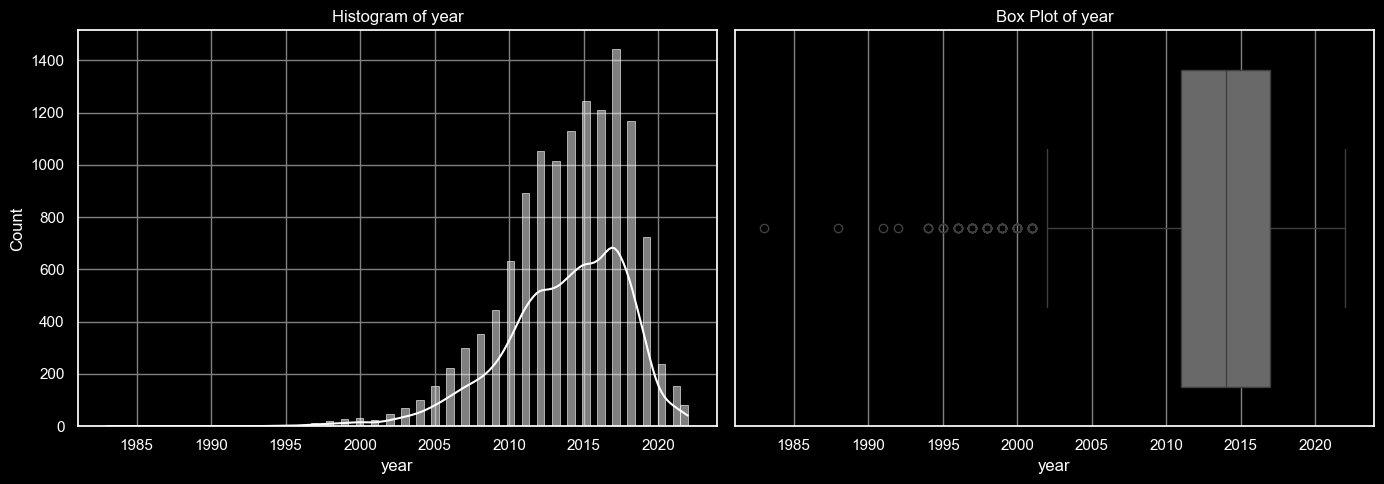

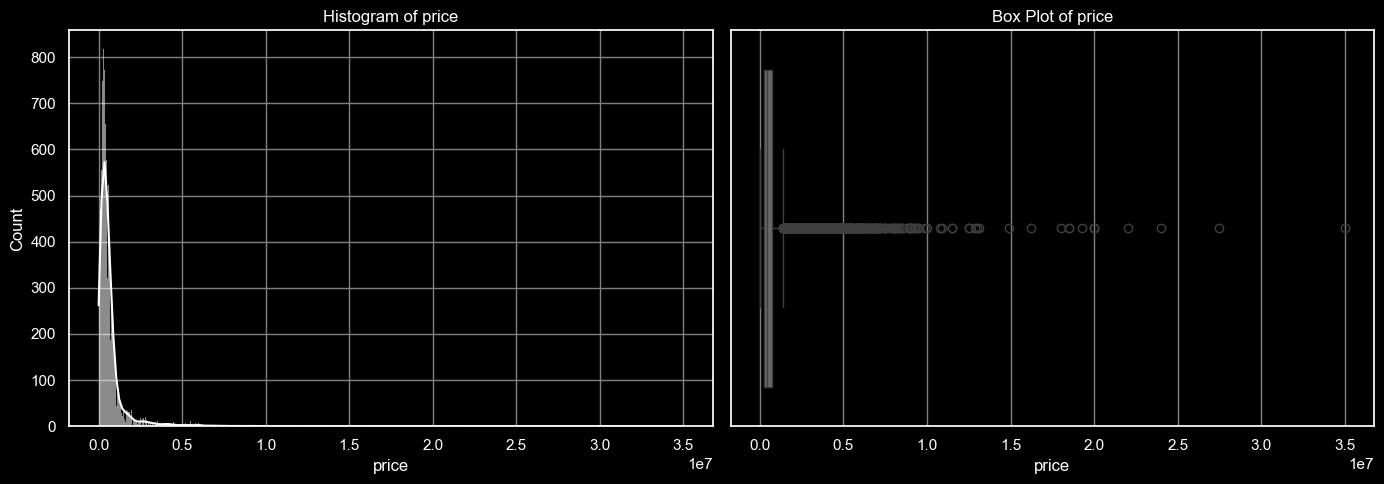

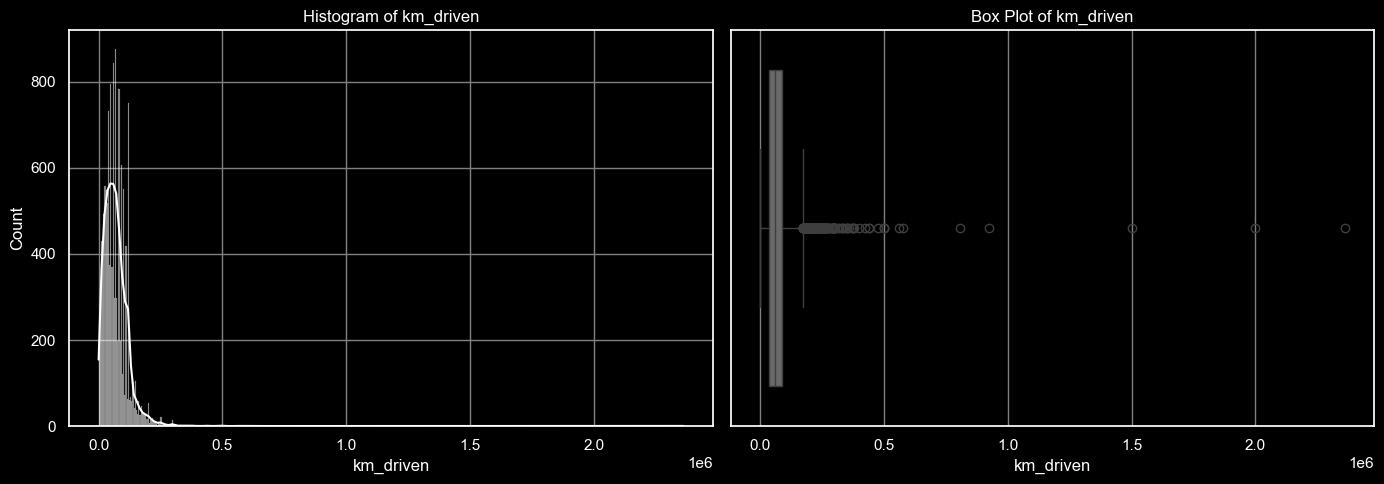

In [23]:
sns.set_theme(style="darkgrid")
sns.set_palette("Greys")

plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["savefig.facecolor"] = "black"
plt.rcParams["axes.edgecolor"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
plt.rcParams["text.color"] = "white"
plt.rcParams["grid.color"] = "gray"

numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("black")

    sns.histplot(df[column].dropna(), kde=True, ax=axes[0], color="white")
    axes[0].set_title(f"Histogram of {column}", color="white")

    sns.boxplot(x=df[column].dropna(), ax=axes[1], color="dimgray")
    axes[1].set_title(f"Box Plot of {column}", color="white")

    plt.tight_layout()
    plt.show()

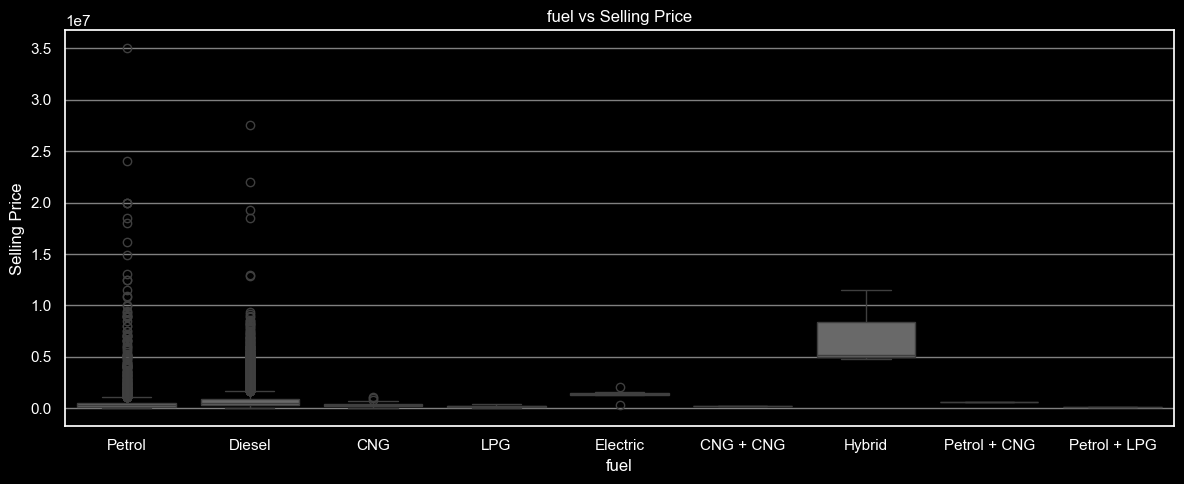

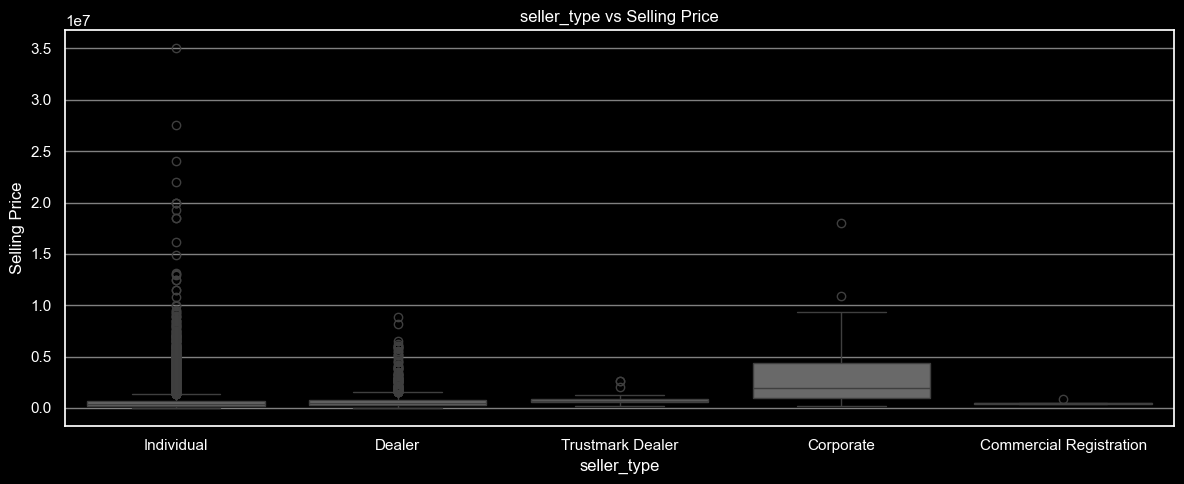

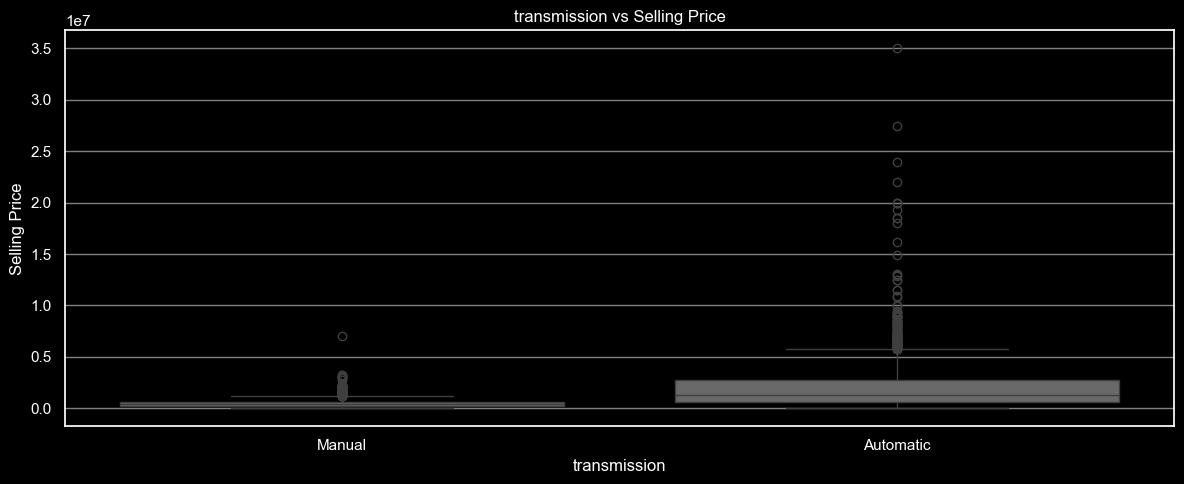

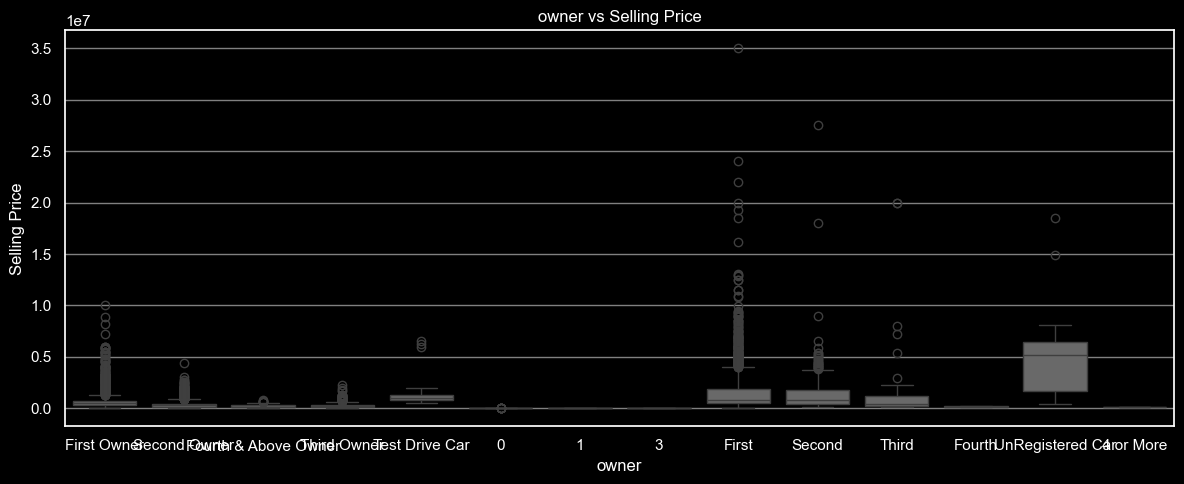

In [24]:
for column in categorical_cols:
    if column != "name": 
      plt.figure(figsize=(12, 5))
      sns.boxplot(data=df, x=column, y="price", color="dimgray")
      plt.title(f"{column} vs Selling Price", color="white")
      plt.xlabel(column, color="white")
      plt.ylabel("Selling Price", color="white")
      plt.tight_layout()
      plt.show()
        
   

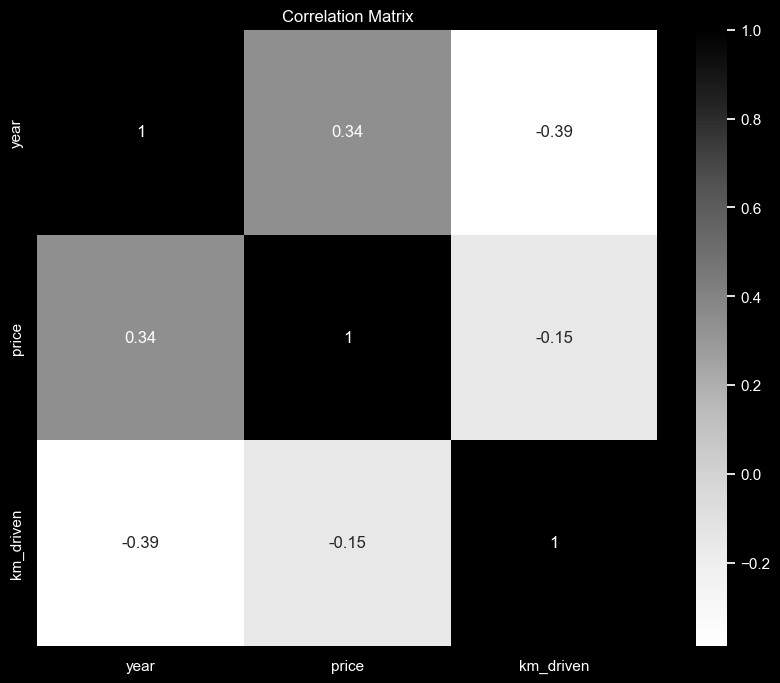

In [25]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Greys", linewidths=0)
plt.title("Correlation Matrix")
plt.show()


In [26]:
# df["km_driven"] = np.log1p(df["km_driven"])
# df["price"]= np.log1p(df["price"])


In [27]:
df["car_age"] = 2026 - df["year"]

In [28]:
cat_cols = ["name", "fuel", "seller_type", "transmission", "owner"]

In [29]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [30]:
df.head()

,year,price,km_driven,car_age,name_Activa 3g,name_Activa 4g,name_Ambassador CLASSIC 1500 DSL AC,name_Ambassador Classic 2000 DSZ AC PS,name_Ambassador Classic 2000 Dsz,name_Ambassador Grand 1500 DSZ BSIII,...,owner_First,owner_First Owner,owner_Fourth,owner_Fourth & Above Owner,owner_Second,owner_Second Owner,owner_Test Drive Car,owner_Third,owner_Third Owner,owner_UnRegistered Car
0,2007,60000.0,70000,19,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,2007,135000.0,50000,19,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,2012,600000.0,100000,14,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,2017,250000.0,46000,9,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,2014,450000.0,141000,12,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [31]:

from sklearn.preprocessing import StandardScaler
x = df.drop(columns=["price", "year"])
y = df["price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Model Score: {model.score(x_test, y_test)}")
print(f"train score: {model.score(x_train, y_train)}")


Mean Squared Error: 313388685174.951
R^2 Score: 0.7225608933135542
Model Score: 0.7225608933135542
train score: 0.773997308300923


In [32]:
model.coef_

array([ -23548.11093764, -433445.14259193,  -18170.11502059, ...,
         -2667.02607431,  -94512.45733425,   88651.53252701],
      shape=(2669,))

In [34]:
pd.Series(model.coef_, index=x.columns).sort_values(ascending=False)

name_Ferrari           324916.482278
name_Mercedes-Benz     297724.424314
name_Rolls-Royce       249968.127747
name_Land Rover        218349.187181
name_Lamborghini       218274.674974
                           ...      
transmission_Manual   -144173.005809
owner_Second Owner    -169987.561627
name_Maruti Suzuki    -181028.264371
owner_First Owner     -216926.535135
car_age               -433445.142592
Length: 2669, dtype: float64

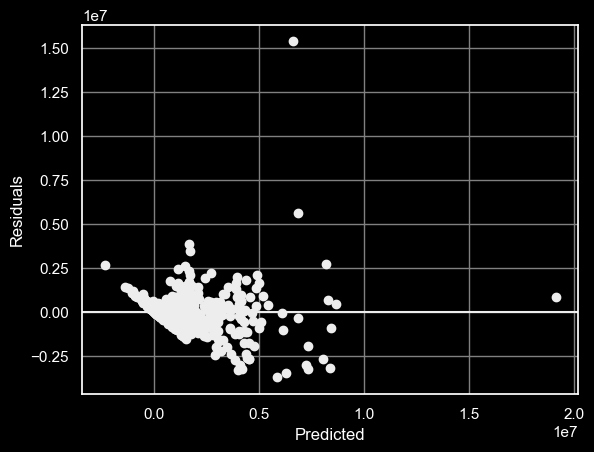

In [33]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()